In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import palettable.wesanderson as wes

import sys
sys.path.insert(0 , './../MDS-UPDRS_Analysis/')
import distributions
from distributions import *
import seaborn as sns

In [5]:
meta = pd.read_csv('./../../data/PPMI/MO-LLM/PPMI_META_LINKAGE.csv')
idiopathic_ids = meta[np.logical_and(meta['Subgroup'] == 'Sporadic' , meta['CONCOHORT_DEFINITION'] == "Parkinson's Disease")]['PATNO'].unique()

In [6]:
events = ['BL', 'V02' , 'V04' ,'V05',
          'V06' ,'V07' , 'V08' ,'V09' , 'V10' ,
          'V11' , 'V12' ,'V13' , 'V14' ,'V15' ,
          'V16' , 'V17' , 'V18','V19' ,'V20' ]

all_events = ['SC', 'BL', 'V01', 'V02', 'V03', 'V04', 'V05',
'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12',
'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19',
'ST', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25'
]

x_list = pd.DataFrame(np.arange(0 , 9.5 , 0.5) , index = events , columns=['response'])

In [7]:
def imputation(data , events) : 
    all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(data['PATNO'].unique())) , 'PATNO' : np.repeat(data['PATNO'].unique() , len(events))})
    
    data = data[data['EVENT_ID'].isin(events)]
    data = pd.merge(all_tmpt , data , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
    data['EVENT_ID'] = pd.Categorical(data['EVENT_ID'] , categories=events , ordered=True)
    
    for patno in data['PATNO'].unique() : 
        row_na = False
        df = data[data['PATNO'] == patno].copy()
        df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
        for i in range(1, len(df) - 1):
            if df.iloc[i].isnull().any():  # Check if NaN exists in the row
                prev_row = df.iloc[i - 1]
                next_row = df.iloc[i + 1]
        
                # Check if the previous and next rows are consecutive
                if row_na : 
                    if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                        df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
                else :
                    if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                            and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                        df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                    elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                        df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                    elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                        df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
    
                row_na = True
            else : 
                row_na = False
        
        df = df.drop('Temp_ID', axis=1)
    
        data[data['PATNO'] == patno] = df.copy()
    
    data = data[np.logical_and(data['PATNO'].isin(idiopathic_ids) , data['EVENT_ID'].isin(events))]

    return data

## Benton Judgement of Line Orientation

In [8]:
bjlo = pd.read_csv('./../Assesment_Exams/Benton_Judgement_of_Line_Orientation_24Feb2025.csv')
bjlo = bjlo[bjlo['PATNO'].isin(idiopathic_ids)]

bjlo = bjlo[['PATNO' , 'EVENT_ID' , 'JLO_TOTRAW']]

In [5]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(bjlo['PATNO'].unique())) , 'PATNO' : np.repeat(bjlo['PATNO'].unique() , len(events))})

bjlo = bjlo[bjlo['EVENT_ID'].isin(events)]
bjlo_impute = pd.merge(all_tmpt , bjlo , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
bjlo_impute['EVENT_ID'] = pd.Categorical(bjlo_impute['EVENT_ID'] , categories=events , ordered=True)

for patno in bjlo_impute['PATNO'].unique() : 
    row_na = False
    df = bjlo_impute[bjlo_impute['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    bjlo_impute[bjlo_impute['PATNO'] == patno] = df.copy()

bjlo = bjlo_impute[np.logical_and(bjlo_impute['PATNO'].isin(idiopathic_ids) , bjlo_impute['EVENT_ID'].isin(events))]
bjlo.to_csv('./../Labels/BJLO.csv')

In [7]:
for feat in bjlo.columns[2:] : 
    bjlo.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/BJLO_{feat}_Scores.csv')

## Clock Drawing

In [10]:
clock = pd.read_csv('./../Assesment_Exams/Clock_Drawing_24Feb2025.csv')
clock = clock[clock['PATNO'].isin(idiopathic_ids)]

clock = clock[['PATNO' , 'EVENT_ID' , 'CLCKTOT']]

In [11]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(clock['PATNO'].unique())) , 'PATNO' : np.repeat(clock['PATNO'].unique() , len(events))})

clock = clock[clock['EVENT_ID'].isin(events)]
clock = pd.merge(all_tmpt , clock , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
clock['EVENT_ID'] = pd.Categorical(clock['EVENT_ID'] , categories=events , ordered=True)

for patno in clock['PATNO'].unique() : 
    row_na = False
    df = clock[clock['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    clock[clock['PATNO'] == patno] = df.copy()

clock = clock[np.logical_and(clock['PATNO'].isin(idiopathic_ids) , clock['EVENT_ID'].isin(events))]
clock.to_csv('./../Labels/ClockDraw.csv')

In [12]:
for feat in clock.columns[2:] : 
    clock.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/Clock_{feat}_Scores.csv')

## Cognitive Change

In [13]:
cogchg = pd.read_csv('./../Assesment_Exams/Cognitive_Change_21Jan2025.csv')
cogchg = cogchg[cogchg['PATNO'].isin(idiopathic_ids)]

cogchg = cogchg[['PATNO' , 'EVENT_ID' , 'COGCHG']]

In [14]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(cogchg['PATNO'].unique())) , 'PATNO' : np.repeat(cogchg['PATNO'].unique() , len(events))})

cogchg = cogchg[cogchg['EVENT_ID'].isin(events)]
cogchg = pd.merge(all_tmpt , cogchg , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
cogchg['EVENT_ID'] = pd.Categorical(cogchg['EVENT_ID'] , categories=events , ordered=True)

for patno in cogchg['PATNO'].unique() : 
    row_na = False
    df = cogchg[cogchg['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    cogchg[cogchg['PATNO'] == patno] = df.copy()

cogchg = cogchg[np.logical_and(cogchg['PATNO'].isin(idiopathic_ids) , cogchg['EVENT_ID'].isin(events))]
cogchg = cogchg.sort_values(['PATNO' , 'EVENT_ID'])
cogchg['CHGSUM'] = cogchg.sort_values(['PATNO' , 'EVENT_ID']).groupby('PATNO')['COGCHG'].cumsum()
cogchg.to_csv('./../Labels/CogChange.csv')

In [15]:
for feat in cogchg.columns[2:] : 
    cogchg.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/COGCHG_{feat}_Scores.csv')

## Epworth Sleepiness Scale

In [8]:
epworth = pd.read_csv('./../Assesment_Exams/Epworth_Sleepiness_Scale_21Jan2025.csv')
epworth = epworth[epworth['PATNO'].isin(idiopathic_ids)]

epworth = epworth[['PATNO' , 'EVENT_ID' ] + [col for col in epworth.columns if 'ESS' in col]]
epworth['Total'] = epworth.iloc[: , 2:].sum(axis=1)

In [9]:
epworth = imputation(epworth , events)

In [10]:
for feat in epworth.columns[2:] : 
    epworth.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/EPWORTH_{feat}_Scores.csv')

## Hopkins verbal learning test

In [18]:
hopkins = pd.read_csv('./../Assesment_Exams/Hopkins_Verbal_Learning_Test_-_Revised_24Feb2025.csv')
hopkins = hopkins[hopkins['PATNO'].isin(idiopathic_ids)]

hopkins = hopkins[['PATNO' , 'EVENT_ID' ,'HVLTRT1','HVLTRT2','HVLTRT3','HVLTRDLY','HVLTREC'] ]
hopkins['Total'] = hopkins.iloc[: , 2:].sum(axis=1)
#hopkins['Total3'] = hopkins.iloc[: , 2:5].sum(axis=1)

In [19]:
hopkins = imputation(hopkins , events)

In [113]:
for feat in hopkins.columns[2:] : 
    hopkins.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/HOPKINSVERBAL_{feat}_Scores.csv')

## Letter Number Sequencing

In [24]:
lnseq = pd.read_csv('./../Assesment_Exams/Letter_-_Number_Sequencing_24Feb2025.csv')
lnseq = lnseq[lnseq['PATNO'].isin(idiopathic_ids)]

lnseq = lnseq[['PATNO' , 'EVENT_ID'] + [col for col in lnseq.columns if 'LNS' in col] ]
#lnseq = lnseq[['PATNO' , 'EVENT_ID' , 'LNS_TOTRAW']]

In [24]:
for feat in lnseq.columns[2:] : 
    lnseq.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/LNSeq_{feat}_Scores.csv')

## Lexical Fluency

In [31]:
lexfl = pd.read_csv('./../Assesment_Exams/Lexical_Fluency_24Feb2025.csv')
lexfl = lexfl[lexfl['PATNO'].isin(idiopathic_ids)]

lexfl = lexfl[['PATNO' , 'EVENT_ID' , 'LXFLUEF','LXFLUEA','LXFLUES']]
lexfl['Total'] = lexfl.iloc[: , 2:].sum(axis=1)

In [32]:
lexfl = imputation(lexfl , events)

In [104]:
for feat in lexfl.columns[2:] : 
    lexfl.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/LexFL_{feat}_Scores.csv')

## Boston Naming Test

In [33]:
bos_name = pd.read_csv('./../Assesment_Exams/Modified_Boston_Naming_Test_24Feb2025.csv')
bos_name = bos_name[bos_name['PATNO'].isin(idiopathic_ids)]

bos_name = bos_name[['PATNO' , 'EVENT_ID' , 'MBSTNSCR','MBSTNCRC','MBSTNCRR']]
bos_name['Total'] = bos_name.iloc[: , 2:].sum(axis=1)

In [34]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(bos_name['PATNO'].unique())) , 'PATNO' : np.repeat(bos_name['PATNO'].unique() , len(events))})

bos_name = bos_name[bos_name['EVENT_ID'].isin(events)]
bos_name = pd.merge(all_tmpt , bos_name , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
bos_name['EVENT_ID'] = pd.Categorical(bos_name['EVENT_ID'] , categories=events , ordered=True)

for patno in bos_name['PATNO'].unique() : 
    row_na = False
    df = bos_name[bos_name['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    bos_name[bos_name['PATNO'] == patno] = df.copy()

bos_name = bos_name[np.logical_and(bos_name['PATNO'].isin(idiopathic_ids) , bos_name['EVENT_ID'].isin(events))]

In [71]:
for feat in bos_name.columns[2:] : 
    bos_name.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/BostonNaming_{feat}_Scores.csv')

## Semantic Fluency

In [35]:
sem_fluency = pd.read_csv('./../Assesment_Exams/Modified_Semantic_Fluency_24Feb2025.csv')
sem_fluency = sem_fluency[sem_fluency['PATNO'].isin(idiopathic_ids)]

sem_fluency = sem_fluency[['PATNO' , 'EVENT_ID' , 'VLTANIM','VLTVEG','VLTFRUIT']]
sem_fluency['Total'] = sem_fluency.iloc[: , 2:].sum(axis=1)

In [36]:
all_tmpt = pd.DataFrame({'EVENT_ID' : np.tile(events , len(sem_fluency['PATNO'].unique())) , 'PATNO' : np.repeat(sem_fluency['PATNO'].unique() , len(events))})

sem_fluency = sem_fluency[sem_fluency['EVENT_ID'].isin(events)]
sem_fluency = pd.merge(all_tmpt , sem_fluency , on = ['PATNO' , 'EVENT_ID'] , how = 'outer')
sem_fluency['EVENT_ID'] = pd.Categorical(sem_fluency['EVENT_ID'] , categories=events , ordered=True)

for patno in sem_fluency['PATNO'].unique() : 
    row_na = False
    df = sem_fluency[sem_fluency['PATNO'] == patno].copy()
    df['Temp_ID'] = df['EVENT_ID'].cat.codes.values
    for i in range(1, len(df) - 1):
        if df.iloc[i].isnull().any():  # Check if NaN exists in the row
            prev_row = df.iloc[i - 1]
            next_row = df.iloc[i + 1]
    
            # Check if the previous and next rows are consecutive
            if row_na : 
                if next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])
            else :
                if (prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] 
                        and next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID']):
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[[i - 1, i + 1]].mean(numeric_only=True))
                elif prev_row['Temp_ID'] + 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i - 1])
                elif next_row['Temp_ID'] - 1 == df.iloc[i]['Temp_ID'] : 
                    df.iloc[i] = df.iloc[i].fillna(df.iloc[i + 1])

            row_na = True
        else : 
            row_na = False
    
    df = df.drop('Temp_ID', axis=1)

    sem_fluency[sem_fluency['PATNO'] == patno] = df.copy()

sem_fluency = sem_fluency[np.logical_and(sem_fluency['PATNO'].isin(idiopathic_ids) , sem_fluency['EVENT_ID'].isin(events))]

In [68]:
for feat in sem_fluency.columns[2:] : 
    sem_fluency.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/SemanticFluency_{feat}_Scores.csv')

## Neuro logical Quality of Life Cognition

In [37]:
cognition = pd.read_csv('./../Assesment_Exams/Neuro_QoL__Cognition_Function_-_Short_Form_21Jan2025.csv')
cognition = cognition[cognition['PATNO'].isin(idiopathic_ids)]

cognition = cognition[['PATNO' , 'EVENT_ID' , 'NQCOG22R','NQCOG24R','NQCOG25R','NQCOG40R']]
cognition['Total'] = cognition.iloc[: , 2:].sum(axis=1)

In [38]:
cognition = imputation(cognition , events)

In [54]:
for feat in cognition.columns[2:] : 
    cognition.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/QOLCOGNITION_{feat}_Scores.csv')

## Neuro QOL Communication

In [39]:
communication = pd.read_csv('./../Assesment_Exams/Neuro_QoL__Communication_-_Short_Form_21Jan2025.csv')
communication = communication[communication['PATNO'].isin(idiopathic_ids)]

communication = communication[['PATNO' , 'EVENT_ID' , 'NQCOG01','NQCOG04','NQCOG08','NQCOG10','NQCOG11']]
communication['Total'] = communication.iloc[: , 2:].sum(axis=1)

In [40]:
communication = imputation(communication , events)

In [57]:
for feat in communication.columns[2:] : 
    communication.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/QOLCOMMUNICATION_{feat}_Scores.csv')

## Neuro QOL Extremity

In [41]:
upper_extremity = pd.read_csv('./../Assesment_Exams/Neuro_QoL__Upper_Extremity_Function_-_Short_Form_21Jan2025.csv')
upper_extremity = upper_extremity[upper_extremity['PATNO'].isin(idiopathic_ids)]

upper_extremity = upper_extremity[['PATNO' , 'EVENT_ID' , 'NQUEX29',
       'NQUEX20', 'NQUEX44', 'NQUEX36', 'NQUEX30', 'NQUEX28', 'NQUEX33',
       'NQUEX37']]
upper_extremity['Total'] = upper_extremity.iloc[: , 2:].sum(axis=1)

In [42]:
upper_extremity = imputation(upper_extremity , events)

In [60]:
for feat in upper_extremity.columns[2:] : 
    upper_extremity.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/QOLUPPERExtremity_{feat}_Scores.csv')

## Neuro QOL Extremity Lower

In [43]:
lower_extremity = pd.read_csv('./../Assesment_Exams/Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_21Jan2025.csv')
lower_extremity = lower_extremity[lower_extremity['PATNO'].isin(idiopathic_ids)]

lower_extremity = lower_extremity[['PATNO' , 'EVENT_ID' , 'NQMOB37',
       'NQMOB30', 'NQMOB26', 'NQMOB32', 'NQMOB25', 'NQMOB33', 'NQMOB31',
       'NQMOB28']]
lower_extremity['Total'] = lower_extremity.iloc[: , 2:].sum(axis=1)

In [44]:
lower_extremity.columns

Index(['PATNO', 'EVENT_ID', 'NQMOB37', 'NQMOB30', 'NQMOB26', 'NQMOB32',
       'NQMOB25', 'NQMOB33', 'NQMOB31', 'NQMOB28', 'Total'],
      dtype='object')

In [45]:
lower_extremity = imputation(lower_extremity , events)

In [64]:
for feat in lower_extremity.columns[2:] : 
    lower_extremity.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/QOLLOWERExtremity_{feat}_Scores.csv')

## Participant Motor Function

In [82]:
motor_func = pd.read_csv('./../Assesment_Exams/Participant_Motor_Function_Questionnaire_21Jan2025.csv')
motor_func = motor_func[motor_func['PATNO'].isin(idiopathic_ids)]

motor_func = motor_func[['PATNO' , 'EVENT_ID' , 'CMPLBY2',
       'TRBUPCHR', 'WRTSMLR', 'VOICSFTR', 'POORBAL', 'FTSTUCK', 'LSSXPRSS',
       'ARMLGSHK', 'TRBBUTTN', 'SHUFFLE', 'MVSLOW', 'TOLDPD']]
motor_func['Total'] = motor_func.iloc[: , 2:].sum(axis=1)

In [83]:
motor_func.columns

Index(['PATNO', 'EVENT_ID', 'CMPLBY2', 'TRBUPCHR', 'WRTSMLR', 'VOICSFTR',
       'POORBAL', 'FTSTUCK', 'LSSXPRSS', 'ARMLGSHK', 'TRBBUTTN', 'SHUFFLE',
       'MVSLOW', 'TOLDPD', 'Total'],
      dtype='object')

In [84]:
motor_func = imputation(motor_func , events)

In [85]:
for feat in motor_func.columns[2:] : 
    motor_func.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/MotorFunction_{feat}_Scores.csv')

In [11]:
epworth

,EVENT_ID,PATNO,ESS1,ESS2,ESS3,ESS4,ESS5,ESS6,ESS7,ESS8,Total
0,BL,3001,1.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,6.0
1,V02,3001,1.0,3.0,1.0,0.0,2.0,0.0,0.0,0.0,7.0
2,V04,3001,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,3.0
3,V05,3001,0.5,1.5,0.5,0.5,2.0,0.0,0.0,0.0,5.0
4,V06,3001,1.0,2.0,1.0,1.0,2.0,0.0,0.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...
11585,V16,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11586,V17,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11587,V18,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11588,V19,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
from factor_analyzer import FactorAnalyzer

def FA(data , n_factors = 3) : 
    # Initialize the FactorAnalyzer object
    fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax")
    
    # Fit the model
    fa.fit(data.iloc[: , 2:-1])
    data_cols = data.iloc[: , 2:-1].columns
    
    # Check Eigenvalues to determine how many factors to use
    ev, v = fa.get_eigenvalues()
    print("Eigenvalues:", ev)
    
    factor_scores = fa.transform(data.iloc[: , 2:-1].dropna())  # Transform the original data set
    # Create a DataFrame from the scores
    factor_scores_df = pd.DataFrame(factor_scores, columns=[f'Factor_{i+1}' for i in range(factor_scores.shape[1])]).add_prefix('data_')
    
    factor_scores_df['PATNO'] = data.dropna(subset=data_cols).reset_index(drop=True)['PATNO']
    factor_scores_df['EVENT_ID'] = data.dropna(subset=data_cols).reset_index(drop=True)['EVENT_ID']
    data_FA = factor_scores_df
    
    loadings = fa.loadings_
    loading_df = pd.DataFrame(loadings, index=data_cols, columns=[f'Factor_{i+1}' for i in range(loadings.shape[1])])
    
    # Print loadings to see the result
    plt.figure(figsize=(10, 10))
    sns.heatmap(loading_df, annot=True, cmap='coolwarm', center=0)
    plt.title('Factor Loadings Heatmap')
    plt.show()

    return data_FA

In [74]:
anx

,EVENT_ID,PATNO,STAIAD1,STAIAD2,STAIAD3,STAIAD4,STAIAD5,STAIAD6,STAIAD7,STAIAD8,...,STAIAD32,STAIAD33,STAIAD34,STAIAD35,STAIAD36,STAIAD37,STAIAD38,STAIAD39,STAIAD40,Total
0,BL,3001,4.0,4.0,2.0,1.0,1.0,1.0,1.0,4.0,...,2.0,4.0,2.0,1.0,4.0,1.0,1.0,4.0,1.0,96.0
1,V02,3001,4.0,4.0,1.0,1.0,4.0,1.0,1.0,3.0,...,2.0,4.0,2.0,1.0,4.0,2.0,1.0,4.0,2.0,96.0
2,V04,3001,4.0,4.0,4.0,4.0,4.0,1.0,1.0,3.0,...,2.0,3.0,2.0,2.0,3.0,1.0,2.0,4.0,2.0,100.0
3,V05,3001,4.0,4.0,2.5,2.5,4.0,1.0,1.0,3.5,...,2.0,3.5,1.5,2.0,3.0,1.5,2.0,4.0,2.0,98.0
4,V06,3001,4.0,4.0,1.0,1.0,4.0,1.0,1.0,4.0,...,2.0,4.0,1.0,2.0,3.0,2.0,2.0,4.0,2.0,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11585,V16,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11586,V17,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11587,V18,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11588,V19,163265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Eigenvalues: [15.81352212  3.72530291  1.90768226  1.15135852  1.02067689  1.00593454
  0.85513094  0.7605553   0.7163744   0.66737838  0.66026337  0.64493742
  0.62313994  0.57586493  0.55278731  0.54183761  0.52453619  0.51006416
  0.48090856  0.47532759  0.45732592  0.44855291  0.4268671   0.40845911
  0.39919468  0.38469083  0.37604989  0.36027976  0.35183691  0.34592221
  0.34287892  0.31981105  0.30699645  0.30035941  0.29731498  0.27400715
  0.26059038  0.25599353  0.24044474  0.22884071]


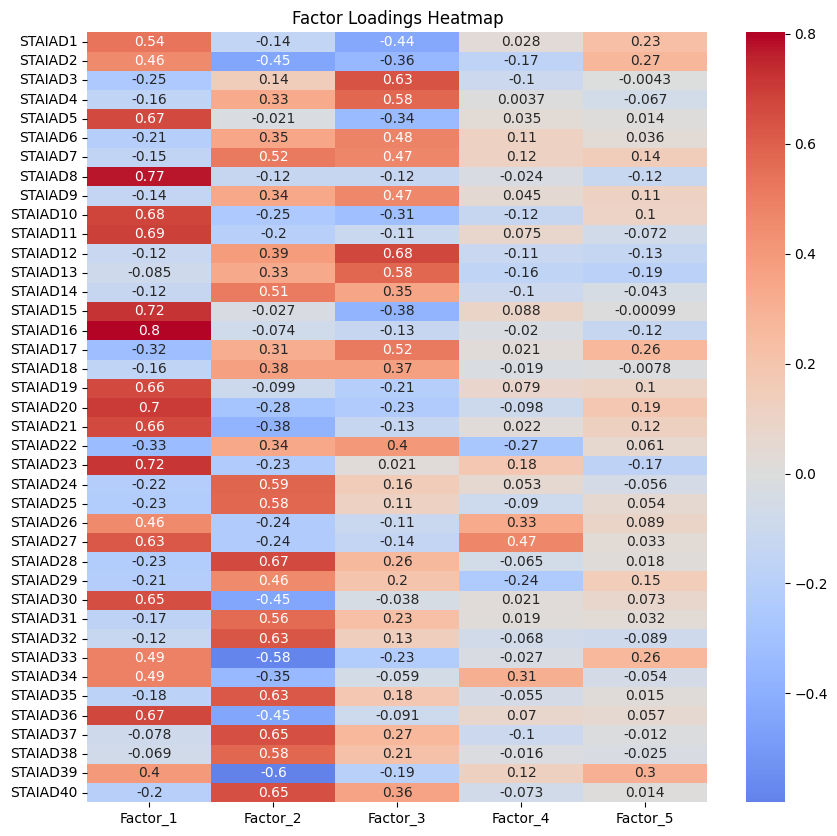

In [73]:
epworth_fa = FA(anx,5)
#epworth_fa.to_csv('./../Labels/FA_BostonName.csv')

## REM

In [46]:
rem = pd.read_csv('./../Assesment_Exams/REM_Sleep_Behavior_Disorder_Questionnaire_21Jan2025.csv')
rem = rem[rem['PATNO'].isin(idiopathic_ids)]

rem = rem[['PATNO' , 'EVENT_ID']+[col for i , col in enumerate(rem.columns) if i > 4 and i < 27 ]]
rem['Total'] = rem.iloc[: , 2:].sum(axis=1)

In [47]:
rem = imputation(rem , events)

In [90]:
for feat in rem.columns[2:] : 
    rem.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/REM_{feat}_Scores.csv')

## Anxiety

In [48]:
anx = pd.read_csv('./../Assesment_Exams/State-Trait_Anxiety_Inventory_21Jan2025.csv')
anx = anx[anx['PATNO'].isin(idiopathic_ids)]

anx = anx[['PATNO' , 'EVENT_ID']+[col for col in anx.columns if 'STAIA' in col]]
anx['Total'] = anx.iloc[: , 2:].sum(axis=1)

In [ ]:
anx = imputation(anx , events)

In [93]:
for feat in anx.columns[2:] : 
    anx.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/Anxiety_{feat}_Scores.csv')

## Symbol Digit Modalities

In [ ]:
symdig = pd.read_csv('./../Assesment_Exams/Symbol_Digit_Modalities_Test_24Feb2025.csv')
symdig = symdig[symdig['PATNO'].isin(idiopathic_ids)]

symdig = symdig[['PATNO' , 'EVENT_ID', 'SDMTOTAL']]

In [ ]:
symdig.columns

In [52]:
symdig = imputation(symdig , events)

In [53]:
for feat in symdig.columns[2:] : 
    symdig.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/SymbolDigit_{feat}_Scores.csv')

## Trail Making

In [98]:
trail = pd.read_csv('./../Assesment_Exams/Trail_Making_A_and_B_24Feb2025.csv')
trail = trail[trail['PATNO'].isin(idiopathic_ids)]

trail = trail[['PATNO' , 'EVENT_ID', 'TMTASEC','TMTBSEC']]
trail['Total'] = trail.iloc[: , 2:].sum(axis=1)

In [99]:
trail = imputation(trail , events)

In [100]:
for feat in trail.columns[2:] : 
    trail.pivot_table(values = feat , columns = 'EVENT_ID' , index = 'PATNO' , observed=False).to_csv(f'./../Labels/TrailMaking_{feat}_Scores.csv')

In [78]:
import os

In [101]:
for item in [i for i in os.listdir('./../Labels/') if 'UPSIT' in i] : 
    os.remove(f'./../Labels/{item}')
    print(item)

UPSIT_SCENT34RESPONSE_Scores.csv
UPSIT_SCENT16RESPONSE_Scores.csv
UPSIT_SCENT14CORRECT_Scores.csv
UPSIT_SCENT08RESPONSE_Scores.csv
UPSIT_SCENT37CORRECT_Scores.csv
UPSIT_SCENT30RESPONSE_Scores.csv
UPSIT_SCENT07RESPONSE_Scores.csv
UPSIT_SCENT29CORRECT_Scores.csv
UPSIT_SCENT11CORRECT_Scores.csv
UPSIT_SCENT03CORRECT_Scores.csv
UPSIT_SCENT25CORRECT_Scores.csv
UPSIT_SCENT36RESPONSE_Scores.csv
UPSIT_SCENT24RESPONSE_Scores.csv
UPSIT_SCENT10RESPONSE_Scores.csv
UPSIT_SCENT08CORRECT_Scores.csv
UPSIT_SCENT40CORRECT_Scores.csv
UPSIT_SCENT18RESPONSE_Scores.csv
UPSIT_SCENT39CORRECT_Scores.csv
UPSIT_SCENT14RESPONSE_Scores.csv
UPSIT_SCENT21RESPONSE_Scores.csv
UPSIT_SCENT02CORRECT_Scores.csv
UPSIT_SCENT18CORRECT_Scores.csv
UPSIT_SCENT05RESPONSE_Scores.csv
UPSIT_SCENT27RESPONSE_Scores.csv
UPSIT_SCENT35RESPONSE_Scores.csv
UPSIT_SCENT39RESPONSE_Scores.csv
UPSIT_SCENT32RESPONSE_Scores.csv
UPSIT_SCENT13RESPONSE_Scores.csv
UPSIT_SCENT12RESPONSE_Scores.csv
UPSIT_SCENT31RESPONSE_Scores.csv
UPSIT_SCENT09CORRECT_